In [10]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

assert tf.__version__.startswith('2'), f'TF 2.x required, got {tf.__version__}'
print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')


TensorFlow: 2.21.0
GPUs available: []


In [11]:
# ── Data paths ───────────────────────────────────────────────────────────────
TRAIN_PKL        = '../data/folds-w-meta.pkl'   # pickle with train folds
TEST_PKL         = '../data/test-w-meta.pkl'     # pickle with test fold
FOLDER_IMAGE_DIR = '../data/classes/'            # optional extra labelled images

# ── Image / training hyper-parameters ────────────────────────────────────────
CLASSIFY_IMAGE_SIZE   = (75, 200)   # native resolution in the pkl files
ESTIMATE_IMAGE_SIZE   = (224, 224)  # EfficientNetB0 expects 224x224
BATCH_SIZE            = 32
CLASSIFIER_EPOCHS     = 10
ESTIMATOR_EPOCHS      = 10
SEED                = 12
EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'

# ── Size-bin definitions ──────────────────────────────────────────────────────
# Upper bound in mm → label string (used as folder names too)

### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = ['25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']

### Original Bin edges and labels (edges in mm, labels in cm)
#BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
#BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None


In [12]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')  # latin1 handles Python-2-saved pkls

train_folds = load_pkl(TRAIN_PKL)
test_folds  = load_pkl(TEST_PKL)

print(f'Train folds: {len(train_folds)}')
print(f'Keys per fold: {list(train_folds[0].keys())}')
print(f'Images in fold 0: {train_folds[0]["data"].shape}')


Train folds: 10
Keys per fold: ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Images in fold 0: (63, 9, 75, 200, 3)


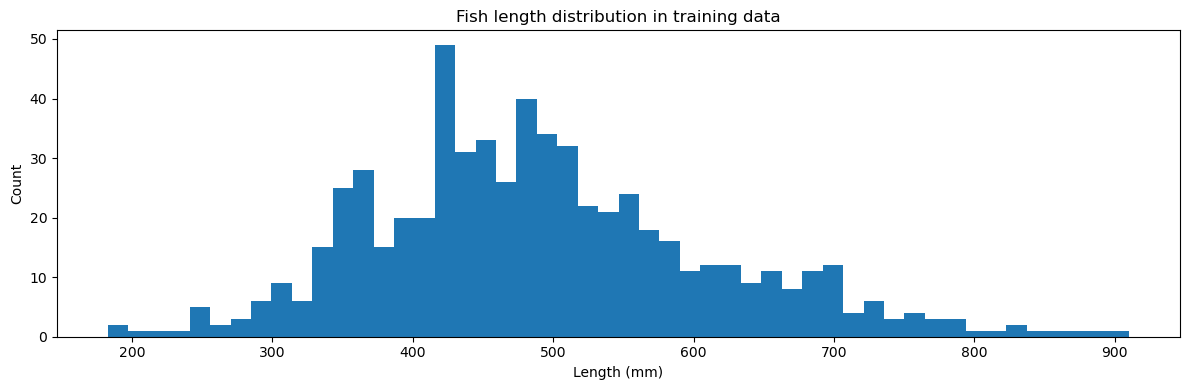

Min: 183mm, Max: 910mm, N: 623


In [13]:
all_lengths = []
for fold in train_folds:
    for length in fold['length']:
        if length is None or str(length).strip() in ('', 'NA'): continue
        all_lengths.append(float(length))

plt.figure(figsize=(12, 4))
plt.hist(all_lengths, bins=50)
plt.xlabel('Length (mm)'); plt.ylabel('Count')
plt.title('Fish length distribution in training data')
plt.tight_layout(); plt.show()

print(f'Min: {min(all_lengths):.0f}mm, Max: {max(all_lengths):.0f}mm, N: {len(all_lengths)}')

# Classification

## Import Classifier

In [14]:
TRAIN_FOLDS = list(range(0, 8))
VAL_FOLD    = 8
TEST_FOLD   = 9

def load_classification_folds(fold_indices, metadata, label_key='class'):
    """Unpack fold dicts into flat (N*9, 75, 200, 3) image arrays."""
    X_list, y_list = [], []
    for i in fold_indices:
        X = metadata[i]['data']       # (N, 9, 75, 200, 3) — 9 views per fish
        y = metadata[i][label_key]    # (N,)
        X = X.reshape(-1, 75, 200, 3)
        y = np.repeat(y, 9)
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_cls_train, y_cls_train = load_classification_folds(TRAIN_FOLDS, train_folds)
X_cls_val,   y_cls_val   = load_classification_folds([VAL_FOLD],  train_folds)
X_cls_test,  y_cls_test  = load_classification_folds([TEST_FOLD], train_folds)

print(f'Train: {X_cls_train.shape}, Val: {X_cls_val.shape}, Test: {X_cls_test.shape}')

# Normalise
X_cls_train = X_cls_train.astype('float32') / 255.0
X_cls_val   = X_cls_val.astype('float32')   / 255.0
X_cls_test  = X_cls_test.astype('float32')  / 255.0

# Encode string species labels → integers
species_le = LabelEncoder()
species_le.fit(np.concatenate([y_cls_train, y_cls_val, y_cls_test]))
y_cls_train_enc = species_le.transform(y_cls_train)
y_cls_val_enc   = species_le.transform(y_cls_val)
y_cls_test_enc  = species_le.transform(y_cls_test)
NUM_SPECIES = len(species_le.classes_)

print(f'Species ({NUM_SPECIES}): {species_le.classes_}')


Train: (4491, 75, 200, 3), Val: (558, 75, 200, 3), Test: (558, 75, 200, 3)
Species (22): ['BHC' 'BUF' 'CC' 'CCF' 'CWS' 'FWD' 'GC' 'GF' 'GS' 'LNG' 'LNS' 'NHS' 'NP'
 'QBS' 'RHS' 'RRS' 'SC' 'SL' 'SMB' 'WB' 'WP' 'WYE']


In [15]:
import keras


classifier = keras.models.load_model("models/classifier.keras")
classifier.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 200,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 75, 200,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 200,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 37, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 37, 100,   │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 37, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 37, 100,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 100,   │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 18, 50,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 18, 50,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 18, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 18, 50,    │      2,112 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 18, 50,    │          0 │ batch_normalizat

 Total params: 952,964 (3.64 MB)

 Trainable params: 317,334 (1.21 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 634,670 (2.42 MB)

# Size Estimator (Continuous)

In [16]:
train_pkl_folds = train_folds
test_pkl_folds  = test_folds
TRAIN_FOLDS = list(range(0, 9))
VAL_FOLDS   = [9]

In [17]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and
    (N,) float32 lengths in mm. Each fish contributes 9 image entries.
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            length_mm = float(length)

            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(length_mm)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Pool with bin-range filter so both arrays stay aligned
def folds_to_arrays_filtered(folds, fold_indices=None):
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped += 1; continue
            length_mm = float(length)
            if length_to_bin(length_mm) is None:
                skipped += 1; continue
            for v in range(raw.shape[0]):
                img = raw[v].astype(np.float32)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(length_mm)
    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [18]:
X_all, y_all = folds_to_arrays(train_pkl_folds + test_pkl_folds)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train lengths — min: {y_train.min():.0f}mm, '
      f'max: {y_train.max():.0f}mm, mean: {y_train.mean():.1f}mm')
print(f'Test  lengths — min: {y_test.min():.0f}mm,  '
      f'max: {y_test.max():.0f}mm, mean: {y_test.mean():.1f}mm')

  Loaded 6246 images from 694 fish, skipped 0 fish

Train: 4996  Val: 625  Test: 625
Train lengths — min: 183mm, max: 910mm, mean: 493.4mm
Test  lengths — min: 183mm,  max: 910mm, mean: 487.4mm


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

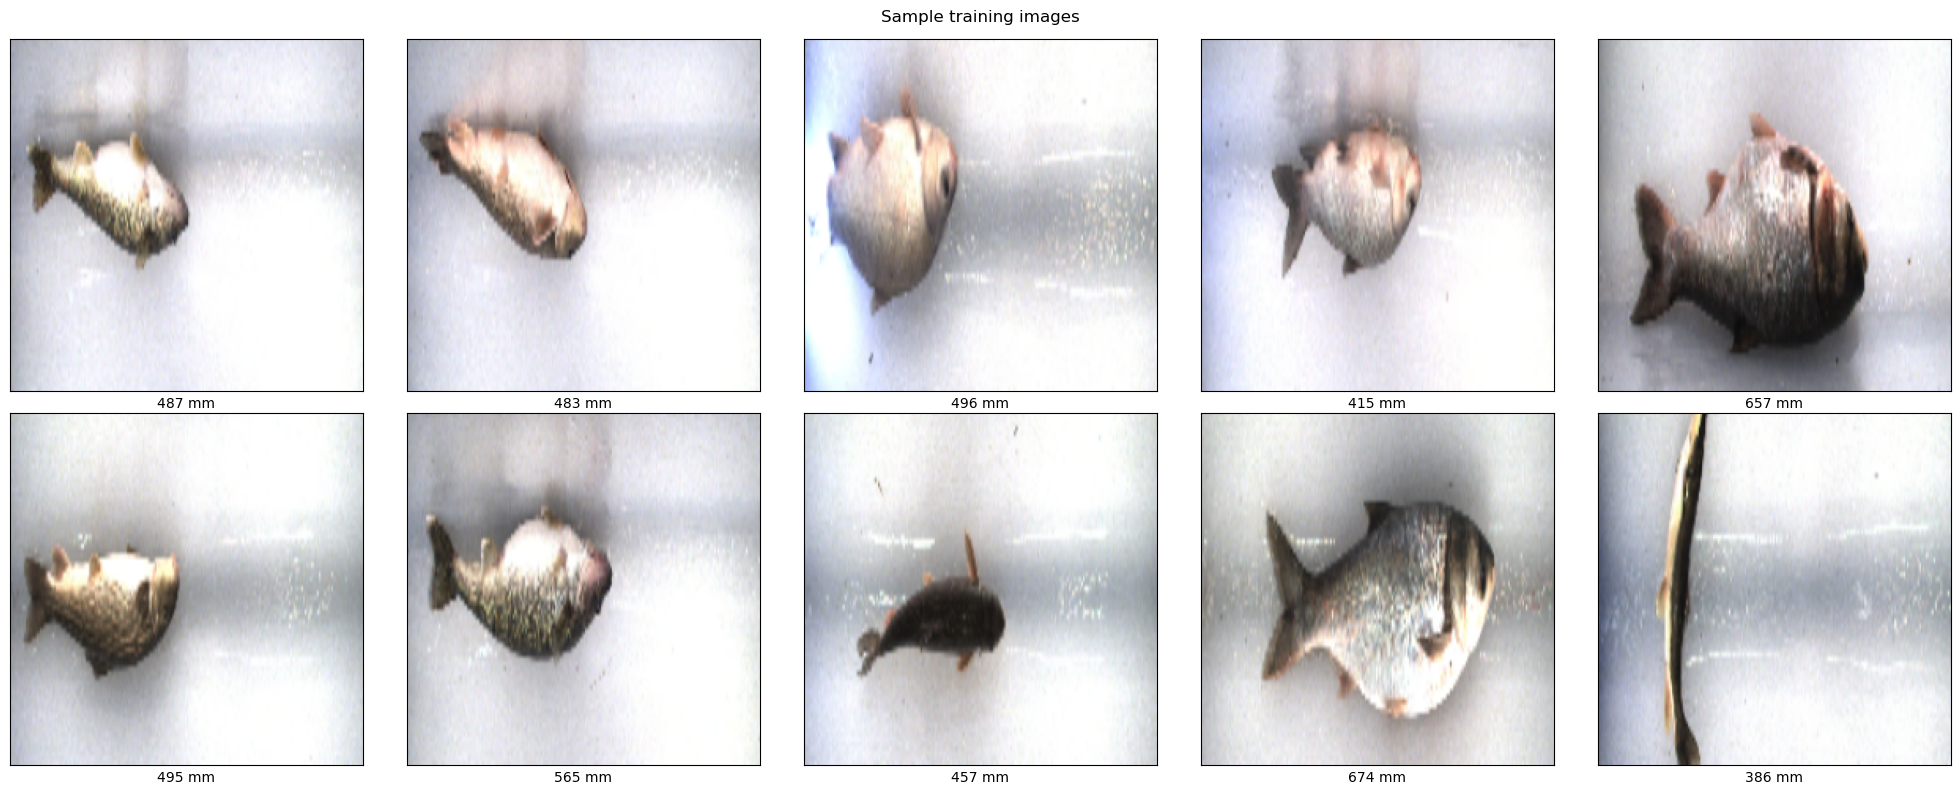

In [20]:
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{lbls[i].numpy():.0f} mm')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build Estimator Model

In [21]:
def build_estimator(trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1),                       # single continuous output, no activation
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse',                                     
        metrics=['mae'],                                
    )
    return model

estimator = estimator = tf.keras.models.load_model("models/estimator_cont.keras", custom_objects={"KerasLayer": hub.KerasLayer}) #build_estimator(trainable_backbone=False)
estimator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 keras_layer_1 (KerasLayer)  (None, 1280)              3413024   
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 3577121 (13.65 MB)
Trainable params: 164097 (641.00 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train Model

In [22]:
early_stop = EarlyStopping(monitor='val_mae', mode='min', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS,
    callbacks=[early_stop],
)


Epoch 1/10



157/157 [==============================] - 18s 108ms/step - loss: 3304.1567 - mae: 44.3011 - val_loss: 2864.8203 - val_mae: 40.3774
Epoch 2/10
157/157 [==============================] - 16s 101ms/step - loss: 3174.9089 - mae: 43.3502 - val_loss: 2826.5662 - val_mae: 40.0000
Epoch 3/10
157/157 [==============================] - 16s 102ms/step - loss: 3190.1562 - mae: 43.3301 - val_loss: 2817.7649 - val_mae: 39.9040
Epoch 4/10
157/157 [==============================] - 16s 103ms/step - loss: 3217.6460 - mae: 43.5174 - val_loss: 2825.9841 - val_mae: 40.3213
Epoch 5/10
157/157 [==============================] - 16s 104ms/step - loss: 3198.7021 - mae: 43.6700 - val_loss: 2802.5337 - val_mae: 39.7208
Epoch 6/10
157/157 [==============================] - 16s 103ms/step - loss: 3126.8091 - mae: 42.8768 - val_loss: 2798.9570 - val_mae: 39.8983
Epoch 7/10
157/157 [==============================] - 16s 104ms/step - loss: 3116.1599 - mae: 43.1592 - val_loss: 2735.1277 - val_mae: 39.6070
Epoch 8/10

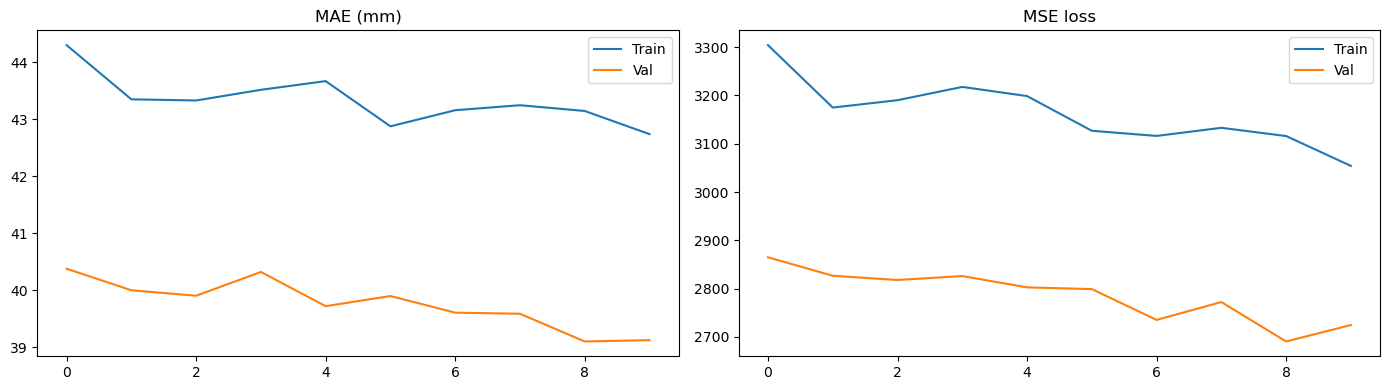

Train  — MSE: 2311.9, MAE: 36.4 mm (3.6 cm)
Val    — MSE: 2690.5, MAE: 39.1 mm (3.9 cm)
Test   — MSE: 2584.7, MAE: 37.7 mm (3.8 cm)


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['mae'],     label='Train')
ax1.plot(history.history['val_mae'], label='Val')
ax1.set_title('MAE (mm)'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('MSE loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, mae = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — MSE: {loss:.1f}, MAE: {mae:.1f} mm ({mae/10:.1f} cm)')

## Combined Inference

Blends the estimator's softmax output with the classifier's species-informed size distribution. **`alpha`** is the weight on the **estimator**; `(1 - alpha)` is the weight on the species-informed prior (`SPECIES_SIZE_PRIOR` from `configs/species_priors_by_code.yaml`).

- **Baselines:** `α=1.0` (estimator only), `α=0.0` (prior only)
- **Sweep:** test many `α` values on the aligned test set and pick the best for the confusion matrix

In [24]:
# ── Biological priors: species mean lengths ───────────────────────────────────
from pathlib import Path

PRIORS_BY_CODE_PATH = Path('../configs/species_priors_by_code.yaml')


def load_species_priors_by_code(path):
    """Load mean/min/max priors from simple YAML (no PyYAML dependency)."""
    priors = {}
    species = None
    for raw in Path(path).read_text().splitlines():
        line = raw.split('#', 1)[0].strip()
        if not line:
            continue
        if line.endswith(':') and ' ' not in line.rstrip(':'):
            species = line[:-1].strip()
            priors[species] = {}
            continue
        if species is None:
            continue
        key, _, val = line.partition(':')
        if val.strip():
            priors[species][key.strip()] = float(val.strip())
    return priors


priors_by_code = load_species_priors_by_code(PRIORS_BY_CODE_PATH)

# Build a vector of species mean lengths (in mm) aligned with species_le.classes_
SPECIES_MEAN_MM = np.zeros(NUM_SPECIES, dtype=np.float32)
for i, code in enumerate(species_le.classes_):
    stats = priors_by_code.get(code)
    if stats:
        SPECIES_MEAN_MM[i] = stats['mean_length_cm'] * 10  # cm → mm
    else:
        SPECIES_MEAN_MM[i] = np.nan  # will flag missing priors

mapped = np.sum(~np.isnan(SPECIES_MEAN_MM))
# Fill missing with global mean so the blend still works
global_mean = np.nanmean(SPECIES_MEAN_MM)
SPECIES_MEAN_MM = np.nan_to_num(SPECIES_MEAN_MM, nan=global_mean)

print(f'Biological priors: {mapped}/{NUM_SPECIES} species with mean length, '
      f'{NUM_SPECIES - mapped} using global mean fallback ({global_mean:.0f} mm)')
print(f'Species means (mm): {dict(zip(species_le.classes_, SPECIES_MEAN_MM))}')

Biological priors: 22/22 species with mean length, 0 using global mean fallback (443 mm)
Species means (mm): {np.str_('BHC'): np.float32(600.0), np.str_('BUF'): np.float32(585.0), np.str_('CC'): np.float32(350.0), np.str_('CCF'): np.float32(570.0), np.str_('CWS'): np.float32(407.0), np.str_('FWD'): np.float32(450.0), np.str_('GC'): np.float32(680.0), np.str_('GF'): np.float32(200.0), np.str_('GS'): np.float32(360.0), np.str_('LNG'): np.float32(670.0), np.str_('LNS'): np.float32(350.0), np.str_('NHS'): np.float32(300.0), np.str_('NP'): np.float32(480.0), np.str_('QBS'): np.float32(520.0), np.str_('RHS'): np.float32(420.0), np.str_('RRS'): np.float32(420.0), np.str_('SC'): np.float32(520.0), np.str_('SL'): np.float32(410.0), np.str_('SMB'): np.float32(350.0), np.str_('WB'): np.float32(320.0), np.str_('WP'): np.float32(250.0), np.str_('WYE'): np.float32(540.0)}


In [25]:
# ── Build aligned test set ────────────────────────────────────────────────────
X_test_75_list  = []
X_est_test_list = []
y_test_mm_list  = []

for fold in test_folds:
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        length_mm = float(length)

        # One 75x200 view (view 0) for classifier
        img_75 = np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32) / 255.0
        X_test_75_list.append(img_75)

        # One 224x224 image for estimator — NO /255, Rescaling layer handles it
        img_224 = tf.image.resize(
            np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32),
            ESTIMATE_IMAGE_SIZE
        ).numpy()
        X_est_test_list.append(img_224)

        y_test_mm_list.append(length_mm)

X_test_75      = np.array(X_test_75_list,  dtype=np.float32)
X_est_test     = np.array(X_est_test_list, dtype=np.float32)
y_test_mm      = np.array(y_test_mm_list,  dtype=np.float32)
print(f'Aligned test set: {len(y_test_mm)} fish')

Aligned test set: 71 fish


Alpha baselines:
  Estimator only (α=1.0)       MAE: 36.3 mm (3.6 cm)  Bin acc: 39.44%
  Prior only (α=0.0)           MAE: 93.0 mm (9.3 cm)  Bin acc: 18.31%
  Equal blend (α=0.5)          MAE: 56.0 mm (5.6 cm)  Bin acc: 28.17%

Best α = 0.95  →  MAE: 35.9 mm (3.6 cm), Bin acc: 39.44%


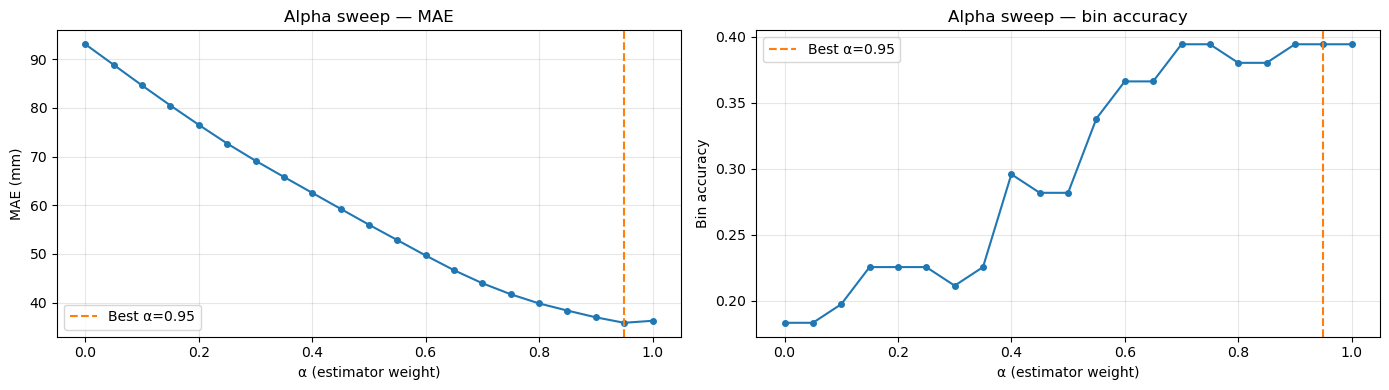

In [26]:
# ── Alpha sweep — continuous blend ────────────────────────────────────────────
# FinalLength = α · vision_estimate + (1 - α) · species_weighted_mean

# Estimator prediction: continuous mm
est_mm = estimator.predict(X_est_test, verbose=0).squeeze()          # (N,)

# Classifier → weighted species mean
species_probs = classifier.predict(X_test_75, verbose=0)             # (N, NUM_SPECIES)
prior_mm = species_probs @ SPECIES_MEAN_MM                           # (N,)


def blend_continuous(alpha):
    return alpha * est_mm + (1.0 - alpha) * prior_mm


def compute_mae(preds_mm):
    return np.mean(np.abs(preds_mm - y_test_mm))


def compute_bin_acc(preds_mm):
    pred_bins = np.array([length_to_bin(L) if length_to_bin(L) is not None
                          else NUM_SIZE_BINS - 1 for L in preds_mm])
    true_bins = np.array([length_to_bin(L) if length_to_bin(L) is not None
                          else NUM_SIZE_BINS - 1 for L in y_test_mm])
    return np.mean(pred_bins == true_bins)


# ── Baselines ─────────────────────────────────────────────────────────────────
ALPHA_BASELINES = [
    (1.0, 'Estimator only (α=1.0)'),
    (0.0, 'Prior only (α=0.0)'),
    (0.5, 'Equal blend (α=0.5)'),
]

print('Alpha baselines:')
for alpha, label in ALPHA_BASELINES:
    preds = blend_continuous(alpha)
    mae = compute_mae(preds)
    bacc = compute_bin_acc(preds)
    print(f'  {label:<28} MAE: {mae:.1f} mm ({mae/10:.1f} cm)  Bin acc: {bacc:.2%}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)
sweep_mae = [compute_mae(blend_continuous(a)) for a in ALPHAS]
sweep_bacc = [compute_bin_acc(blend_continuous(a)) for a in ALPHAS]

best_idx   = int(np.argmin(sweep_mae))  # minimize MAE, not maximize accuracy
BEST_ALPHA = float(ALPHAS[best_idx])
best_mae   = sweep_mae[best_idx]
best_bacc  = sweep_bacc[best_idx]

print(f'\nBest α = {BEST_ALPHA:.2f}  →  MAE: {best_mae:.1f} mm ({best_mae/10:.1f} cm), '
      f'Bin acc: {best_bacc:.2%}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(ALPHAS, sweep_mae, marker='o', markersize=4)
ax1.axvline(BEST_ALPHA, color='C1', ls='--', label=f'Best α={BEST_ALPHA:.2f}')
ax1.set_xlabel('α (estimator weight)'); ax1.set_ylabel('MAE (mm)')
ax1.set_title('Alpha sweep — MAE'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ALPHAS, sweep_bacc, marker='o', markersize=4)
ax2.axvline(BEST_ALPHA, color='C1', ls='--', label=f'Best α={BEST_ALPHA:.2f}')
ax2.set_xlabel('α (estimator weight)'); ax2.set_ylabel('Bin accuracy')
ax2.set_title('Alpha sweep — bin accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

pred_mm = blend_continuous(BEST_ALPHA)

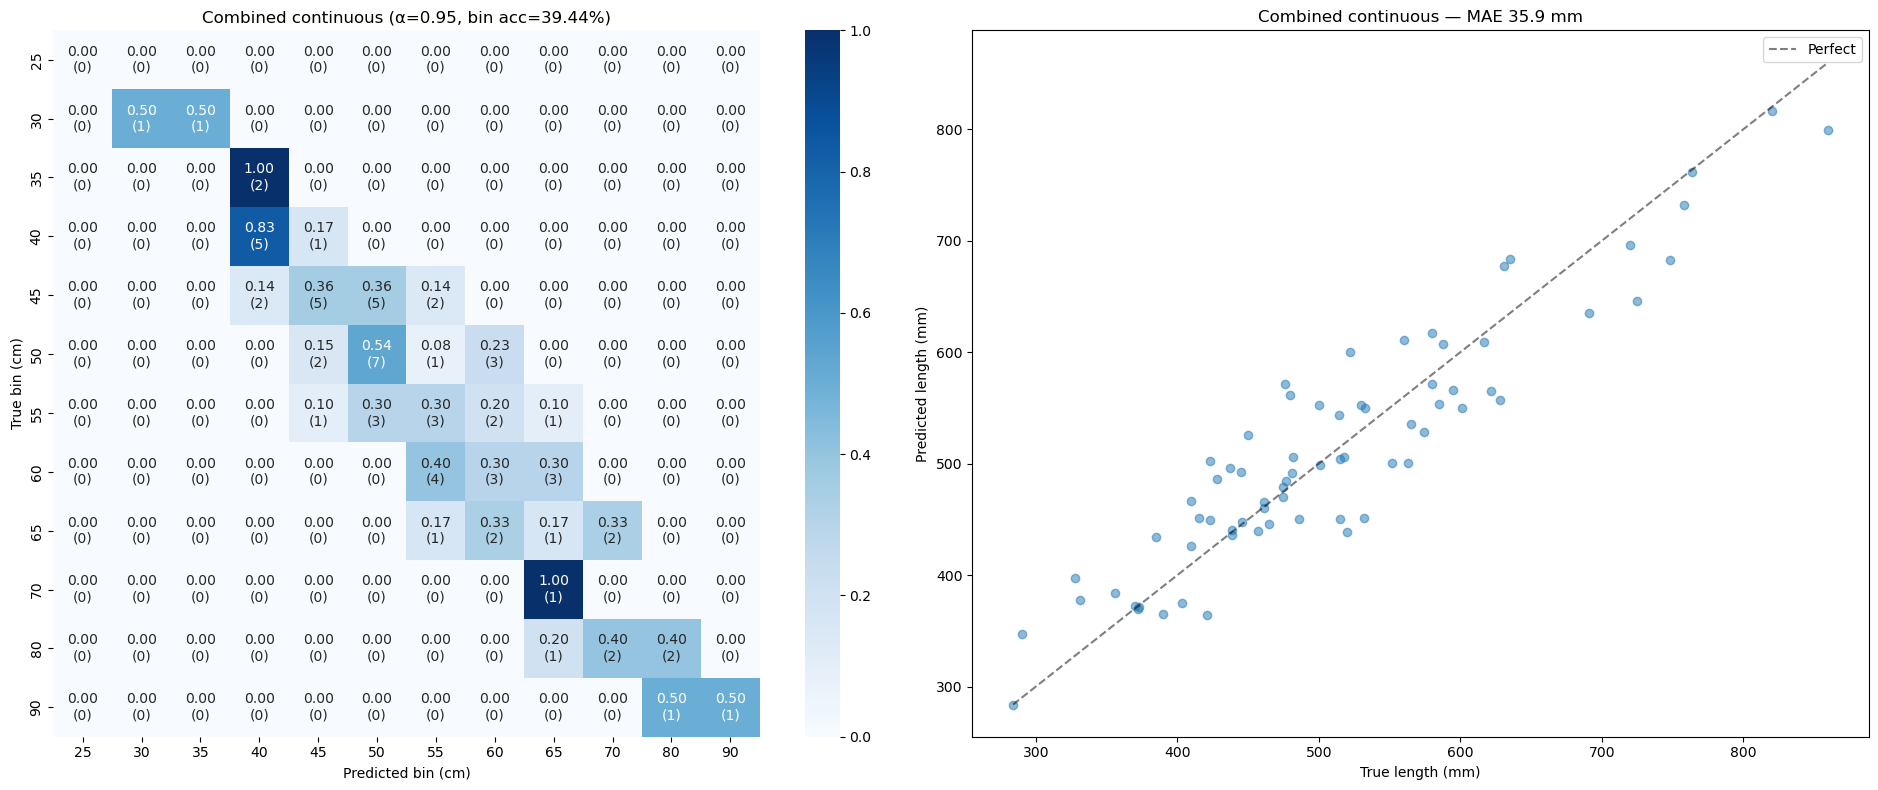

In [27]:
# ── Confusion matrix and scatter at best α ────────────────────────────────────

def lengths_to_bins(lengths_mm):
    bins = []
    for L in lengths_mm:
        b = length_to_bin(L)
        bins.append(b if b is not None else NUM_SIZE_BINS - 1)
    return np.array(bins, dtype=int)

y_pred_bins = lengths_to_bins(pred_mm)
y_true_bins = lengths_to_bins(y_test_mm)

cm      = confusion_matrix(y_true_bins, y_pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 8))

# Confusion matrix
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1, ax=ax1)
ax1.set_title(f'Combined continuous (α={BEST_ALPHA:.2f}, bin acc={best_bacc:.2%})')
ax1.set_ylabel('True bin (cm)'); ax1.set_xlabel('Predicted bin (cm)')

# Scatter
lo = min(y_test_mm.min(), pred_mm.min())
hi = max(y_test_mm.max(), pred_mm.max())
ax2.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Perfect')
ax2.scatter(y_test_mm, pred_mm, alpha=0.5)
ax2.set_xlabel('True length (mm)'); ax2.set_ylabel('Predicted length (mm)')
ax2.set_title(f'Combined continuous — MAE {best_mae:.1f} mm')
ax2.legend()

plt.tight_layout(); plt.show()

## Eval

In [28]:
# ── 20-run evaluation with per-run alpha selection (continuous) ───────────────

NUM_RUNS = 20
ESTIMATOR_EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE
ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)

# 1. Pool ALL data at both resolutions ─────────────────────────────────────────
print('Pooling all data at 224x224 for estimator...')
X_all_224, y_all_mm = folds_to_arrays_filtered(train_folds + test_folds)

print('Pooling all data at 75x200 for classifier...')
X_all_75 = []
for fold in (train_folds + test_folds):
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        length_mm = float(length)
        if length_to_bin(length_mm) is None: continue
        for v in range(raw.shape[0]):
            img_75 = raw[v].astype(np.float32) / 255.0
            X_all_75.append(img_75)

X_all_75 = np.array(X_all_75, dtype=np.float32)
print(f'Total: {X_all_224.shape[0]} images (224x224), {X_all_75.shape[0]} images (75x200)')
assert len(X_all_224) == len(X_all_75), "Image counts don't match"

def lengths_to_bins(lengths_mm):
    bins = []
    for L in lengths_mm:
        b = length_to_bin(L)
        bins.append(b if b is not None else NUM_SIZE_BINS - 1)
    return np.array(bins, dtype=int)

# 2. Run loop ──────────────────────────────────────────────────────────────────
results = []
all_cm_estimator = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)
all_cm_combined  = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)

for run in range(NUM_RUNS):
    seed = run
    print(f'═══ Run {run + 1}/{NUM_RUNS}  (seed={seed}) ═══')

    # Split at image level
    idx = np.arange(len(X_all_224))
    idx_tr, idx_temp = train_test_split(idx, test_size=0.2, random_state=seed)
    idx_val, idx_te  = train_test_split(idx_temp, test_size=0.5, random_state=seed)

    X_tr_224 = X_all_224[idx_tr]
    y_tr     = y_all_mm[idx_tr]
    X_v_224  = X_all_224[idx_val]
    X_v_75   = X_all_75[idx_val]
    y_v      = y_all_mm[idx_val]
    X_te_224 = X_all_224[idx_te]
    X_te_75  = X_all_75[idx_te]
    y_te     = y_all_mm[idx_te]

    # Build datasets
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr_224, y_tr))
                .shuffle(len(X_tr_224), seed=seed).batch(BATCH_SIZE).prefetch(AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_v_224, y_v))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

    # Fresh estimator each run
    model = build_estimator(trainable_backbone=False)
    early_stop = EarlyStopping(monitor='val_mae', mode='min', patience=3, restore_best_weights=True)
    model.fit(train_ds, validation_data=val_ds, epochs=ESTIMATOR_EPOCHS,
              callbacks=[early_stop], verbose=0)

    # ── Predictions on val and test ───────────────────────────────────────
    est_mm_val  = model.predict(X_v_224, verbose=0).squeeze()
    sp_probs_val = classifier.predict(X_v_75, verbose=0)
    prior_mm_val = sp_probs_val @ SPECIES_MEAN_MM

    est_mm_te   = model.predict(X_te_224, verbose=0).squeeze()
    sp_probs_te  = classifier.predict(X_te_75, verbose=0)
    prior_mm_te  = sp_probs_te @ SPECIES_MEAN_MM

    # ── Sweep alpha on VAL set (minimize MAE) ─────────────────────────────
    val_maes = []
    for a in ALPHAS:
        blended_val = a * est_mm_val + (1 - a) * prior_mm_val
        val_maes.append(np.mean(np.abs(blended_val - y_v)))

    run_best_alpha = float(ALPHAS[np.argmin(val_maes)])

    # ── Evaluate on TEST set ──────────────────────────────────────────────
    # Estimator only
    est_mae  = np.mean(np.abs(est_mm_te - y_te))
    est_rmse = np.sqrt(np.mean((est_mm_te - y_te) ** 2))
    est_bins = lengths_to_bins(est_mm_te)
    true_bins = lengths_to_bins(y_te)
    est_bacc = np.mean(est_bins == true_bins)

    # Combined at this run's best alpha
    comb_mm   = run_best_alpha * est_mm_te + (1 - run_best_alpha) * prior_mm_te
    comb_mae  = np.mean(np.abs(comb_mm - y_te))
    comb_rmse = np.sqrt(np.mean((comb_mm - y_te) ** 2))
    comb_bins = lengths_to_bins(comb_mm)
    comb_bacc = np.mean(comb_bins == true_bins)

    results.append({
        'run': run + 1,
        'seed': seed,
        'best_alpha': run_best_alpha,
        'est_mae_mm': est_mae,
        'est_rmse_mm': est_rmse,
        'est_bin_acc': est_bacc,
        'comb_mae_mm': comb_mae,
        'comb_rmse_mm': comb_rmse,
        'comb_bin_acc': comb_bacc,
    })
    print(f'  Best α (val): {run_best_alpha:.2f}')
    print(f'  Estimator — MAE: {est_mae:.1f} mm  RMSE: {est_rmse:.1f} mm  Bin acc: {est_bacc:.2%}')
    print(f'  Combined  — MAE: {comb_mae:.1f} mm  RMSE: {comb_rmse:.1f} mm  Bin acc: {comb_bacc:.2%}\n')

    # Accumulate normalised confusion matrices
    for preds, cm_accum in [(est_bins, all_cm_estimator), (comb_bins, all_cm_combined)]:
        cm = confusion_matrix(true_bins, preds, labels=list(range(NUM_SIZE_BINS)))
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_norm = np.where(row_sum == 0, 0, cm / np.where(row_sum == 0, 1, row_sum))
        cm_accum += cm_norm

    # Free memory
    del model, est_mm_val, est_mm_te, sp_probs_val, sp_probs_te
    del X_tr_224, X_v_224, X_v_75, X_te_224, X_te_75
    tf.keras.backend.clear_session()

Pooling all data at 224x224 for estimator...
  Loaded 6237 images from 693 fish, skipped 1 fish
Pooling all data at 75x200 for classifier...
Total: 6237 images (224x224), 6237 images (75x200)
═══ Run 1/20  (seed=0) ═══
  Best α (val): 0.90
  Estimator — MAE: 41.4 mm  RMSE: 53.9 mm  Bin acc: 36.38%
  Combined  — MAE: 41.0 mm  RMSE: 53.4 mm  Bin acc: 37.34%

═══ Run 2/20  (seed=1) ═══
  Best α (val): 0.90
  Estimator — MAE: 41.5 mm  RMSE: 54.4 mm  Bin acc: 40.22%
  Combined  — MAE: 40.7 mm  RMSE: 53.4 mm  Bin acc: 39.74%

═══ Run 3/20  (seed=2) ═══
  Best α (val): 0.95
  Estimator — MAE: 40.1 mm  RMSE: 51.9 mm  Bin acc: 40.87%
  Combined  — MAE: 39.6 mm  RMSE: 51.0 mm  Bin acc: 41.99%

═══ Run 4/20  (seed=3) ═══
  Best α (val): 0.95
  Estimator — MAE: 39.9 mm  RMSE: 52.0 mm  Bin acc: 40.22%
  Combined  — MAE: 38.9 mm  RMSE: 50.7 mm  Bin acc: 40.54%

═══ Run 5/20  (seed=4) ═══
  Best α (val): 0.95
  Estimator — MAE: 39.8 mm  RMSE: 52.1 mm  Bin acc: 37.02%
  Combined  — MAE: 39.6 mm  RMSE:

In [29]:
df = pd.DataFrame(results)
print(df.to_string(index=False))

print(f'\nBest α across runs: {df["best_alpha"].mean():.2f} ± {df["best_alpha"].std():.2f}')
print(f'  Range: {df["best_alpha"].min():.2f} — {df["best_alpha"].max():.2f}')

print(f'\n{"":30s} {"MAE (mm)":<20s} {"RMSE (mm)":<20s} {"Bin accuracy":<20s}')
print(f'{"Estimator only:":<30s} '
      f'{df["est_mae_mm"].mean():.1f} ± {df["est_mae_mm"].std():.1f}      '
      f'{df["est_rmse_mm"].mean():.1f} ± {df["est_rmse_mm"].std():.1f}      '
      f'{df["est_bin_acc"].mean():.2%} ± {df["est_bin_acc"].std():.2%}')
print(f'{"Combined (per-run α):":<30s} '
      f'{df["comb_mae_mm"].mean():.1f} ± {df["comb_mae_mm"].std():.1f}      '
      f'{df["comb_rmse_mm"].mean():.1f} ± {df["comb_rmse_mm"].std():.1f}      '
      f'{df["comb_bin_acc"].mean():.2%} ± {df["comb_bin_acc"].std():.2%}')
print(f'\nΔ MAE:          {df["comb_mae_mm"].mean() - df["est_mae_mm"].mean():+.1f} mm')
print(f'Δ Bin accuracy: {df["comb_bin_acc"].mean() - df["est_bin_acc"].mean():+.2%}')

 run  seed  best_alpha  est_mae_mm  est_rmse_mm  est_bin_acc  comb_mae_mm  comb_rmse_mm  comb_bin_acc
   1     0        0.90   41.429192    53.869370     0.363782    41.032013     53.360764      0.373397
   2     1        0.90   41.471725    54.381527     0.402244    40.671974     53.354248      0.397436
   3     2        0.95   40.079266    51.904720     0.408654    39.569218     51.025333      0.419872
   4     3        0.95   39.937843    52.034847     0.402244    38.852783     50.660610      0.405449
   5     4        0.95   39.819870    52.087589     0.370192    39.618591     51.734871      0.386218
   6     5        0.90   40.106438    53.826298     0.410256    39.976406     52.882198      0.403846
   7     6        0.90   41.038483    54.673965     0.405449    39.848438     53.187931      0.400641
   8     7        0.95   41.353302    56.254707     0.407051    40.569420     55.353661      0.408654
   9     8        0.95   41.844898    56.008377     0.402244    41.421101     55.5

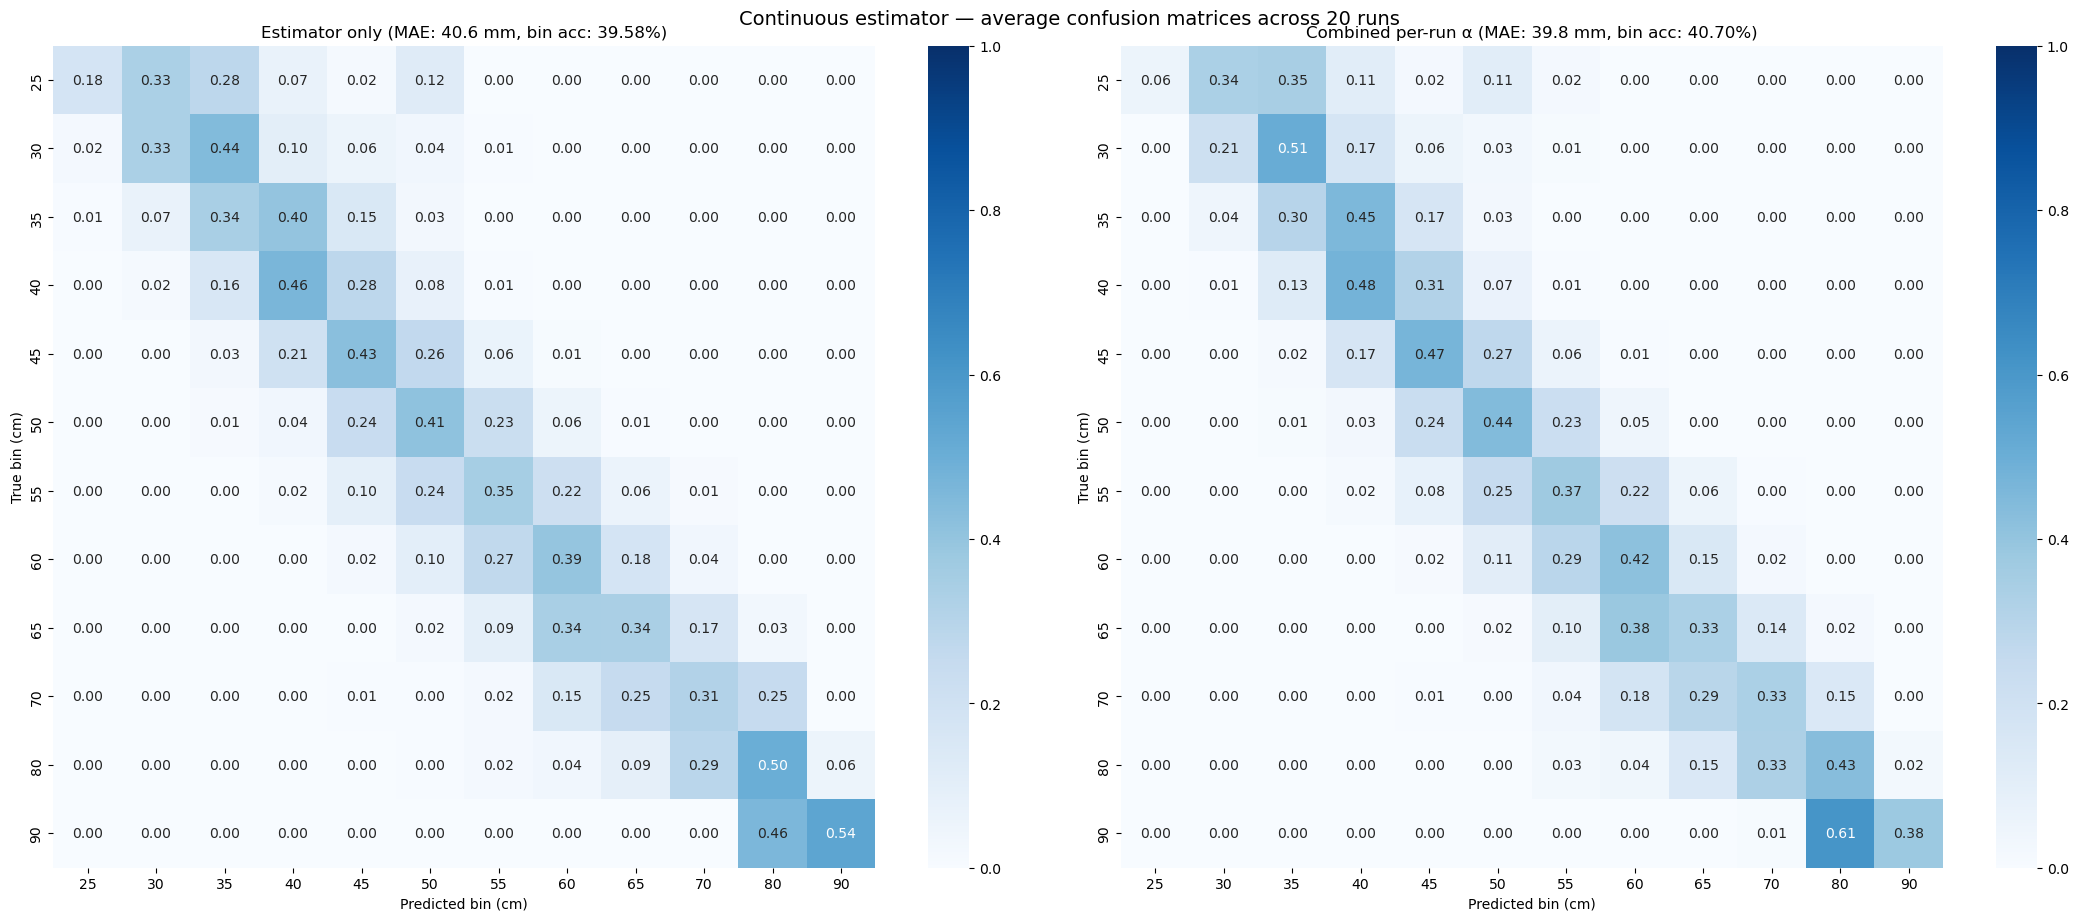

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

for ax, cm_accum, title in [
    (ax1, all_cm_estimator,
     f'Estimator only (MAE: {df["est_mae_mm"].mean():.1f} mm, bin acc: {df["est_bin_acc"].mean():.2%})'),
    (ax2, all_cm_combined,
     f'Combined per-run α (MAE: {df["comb_mae_mm"].mean():.1f} mm, bin acc: {df["comb_bin_acc"].mean():.2%})'),
]:
    avg = cm_accum / NUM_RUNS
    sns.heatmap(avg, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
                cmap='Blues', annot=True, fmt='.2f', square=True, vmin=0, vmax=1, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True bin (cm)')
    ax.set_xlabel('Predicted bin (cm)')

plt.suptitle(f'Continuous estimator — average confusion matrices across {NUM_RUNS} runs', fontsize=14)
plt.tight_layout()
plt.show()

## Experiement with calculating priors from training data

In [37]:
# ── Build species array aligned with X_all_224 / X_all_75 (continuous version) ─
# The cell-25 pooling loop above didn't keep species labels — rebuild them here
# using the SAME filter logic so the arrays stay aligned row-for-row.
y_all_species = []
for fold in (train_folds + test_folds):
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        length_mm = float(length)
        if length_to_bin(length_mm) is None: continue
        species = fold['class'][i]
        for v in range(raw.shape[0]):
            y_all_species.append(species)
y_all_species = np.array(y_all_species)

assert len(y_all_species) == len(X_all_224) == len(y_all_mm), \
    'Species array length mismatch — pooling filter logic must match cell 25'

# Confirm 9 consecutive rows = same fish (otherwise idx[idx%9==0] dedup breaks)
for i in range(0, min(len(y_all_species), 9 * 100), 9):
    assert (y_all_species[i:i+9] == y_all_species[i]).all(), \
        f'Views not contiguous at index {i}'
    assert (y_all_mm[i:i+9] == y_all_mm[i]).all(), \
        f'Lengths not contiguous at index {i}'
print(f'Species array built: {len(y_all_species)} rows, '
      f'{len(np.unique(y_all_species))} unique species.')
print('Fish-level dedup assumption holds (9 consecutive rows = one fish).')

Species array built: 6237 rows, 22 unique species.
Fish-level dedup assumption holds (9 consecutive rows = one fish).


In [38]:
# ── Empirical species mean lengths from training fish ─────────────────────────
def build_empirical_species_means(
    species_classes,
    train_species,        # (N_fish,) species code, deduplicated to fish level
    train_lengths_mm,     # (N_fish,) length in mm, deduplicated to fish level
    method='mean',        # 'mean' | 'median' | 'shrinkage' | 'hybrid'
    tau=5.0,              # shrinkage: pseudocount toward fallback mean
    lam=0.7,              # hybrid: weight on empirical
    fallback_means=None,  # (N_species,) YAML means; required for shrinkage/hybrid
                          #   and for zero-count species fallback
):
    """
    Compute per-species mean lengths from training labels.

    IMPORTANT: pass fish-level (deduplicated) arrays. 9 views per fish would
    not change the result mathematically but would mis-calibrate the
    shrinkage pseudocount τ (which counts as if each view were independent).
    """
    num_species = len(species_classes)
    out = np.zeros(num_species, dtype=np.float32)
    species_to_idx = {s: i for i, s in enumerate(species_classes)}

    # Group lengths by species
    by_species = {i: [] for i in range(num_species)}
    for sp, L in zip(train_species, train_lengths_mm):
        if sp in species_to_idx:
            by_species[species_to_idx[sp]].append(L)

    for i in range(num_species):
        vals = np.array(by_species[i], dtype=np.float64)
        n = len(vals)
        if n == 0:
            out[i] = fallback_means[i] if fallback_means is not None else 0.0
            continue
        if method == 'mean':
            out[i] = vals.mean()
        elif method == 'median':
            out[i] = np.median(vals)
        elif method == 'shrinkage':
            assert fallback_means is not None, "shrinkage requires fallback_means"
            out[i] = (n * vals.mean() + tau * fallback_means[i]) / (n + tau)
        elif method == 'hybrid':
            assert fallback_means is not None, "hybrid requires fallback_means"
            out[i] = lam * vals.mean() + (1 - lam) * fallback_means[i]
        else:
            raise ValueError(f'unknown method: {method}')

    return out

In [39]:
# ── 20-run paired evaluation: YAML vs training-derived species means ──────────
from scipy import stats

PRIOR_CONFIGS = [
    ('yaml',               {}),                                  # baseline
    ('empirical_mean',     {'method': 'mean'}),                  # raw mean
    ('empirical_median',   {'method': 'median'}),                # outlier-robust
    ('shrinkage_tau_5',    {'method': 'shrinkage', 'tau': 5.0}), # Bayesian smoothing
    ('hybrid_lam_0.25',    {'method': 'hybrid', 'lam': 0.25}),
    ('hybrid_lam_0.50',    {'method': 'hybrid', 'lam': 0.50}),
    ('hybrid_lam_0.75',    {'method': 'hybrid', 'lam': 0.75}),
]

NUM_RUNS_EXP = 20
ESTIMATOR_EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE
ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)

results_by_config = {name: [] for name, _ in PRIOR_CONFIGS}

for run in range(NUM_RUNS_EXP):
    seed = run
    print(f'═══ Run {run + 1}/{NUM_RUNS_EXP}  (seed={seed}) ═══')

    # Split (same logic as cell 25 so results are paired with the original eval)
    idx = np.arange(len(X_all_224))
    idx_tr, idx_temp = train_test_split(idx, test_size=0.2, random_state=seed)
    idx_val, idx_te  = train_test_split(idx_temp, test_size=0.5, random_state=seed)

    X_tr_224 = X_all_224[idx_tr];  y_tr = y_all_mm[idx_tr]
    X_v_224  = X_all_224[idx_val]; X_v_75 = X_all_75[idx_val]; y_v = y_all_mm[idx_val]
    X_te_224 = X_all_224[idx_te];  X_te_75 = X_all_75[idx_te]; y_te = y_all_mm[idx_te]

    # Train fresh estimator (shared across prior configs this run)
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr_224, y_tr))
                .shuffle(len(X_tr_224), seed=seed).batch(BATCH_SIZE).prefetch(AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_v_224, y_v))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))
    model = build_estimator(trainable_backbone=False)
    early_stop = EarlyStopping(monitor='val_mae', mode='min', patience=3, restore_best_weights=True)
    model.fit(train_ds, validation_data=val_ds, epochs=ESTIMATOR_EPOCHS,
              callbacks=[early_stop], verbose=0)

    # Predict once — reused for every prior config
    est_mm_val   = model.predict(X_v_224, verbose=0).squeeze()
    sp_probs_val = classifier.predict(X_v_75, verbose=0)
    est_mm_te    = model.predict(X_te_224, verbose=0).squeeze()
    sp_probs_te  = classifier.predict(X_te_75, verbose=0)

    # Estimator-only metrics (config-independent baseline for this run)
    est_mae   = float(np.mean(np.abs(est_mm_te - y_te)))
    est_rmse  = float(np.sqrt(np.mean((est_mm_te - y_te) ** 2)))
    true_bins = lengths_to_bins(y_te)
    est_bacc  = float(np.mean(lengths_to_bins(est_mm_te) == true_bins))

    # Fish-level training labels for empirical priors (NO LEAKAGE: only idx_tr used)
    train_fish_idx     = idx_tr[idx_tr % 9 == 0]
    train_species_fish = y_all_species[train_fish_idx]
    train_lengths_fish = y_all_mm[train_fish_idx]

    for name, kwargs in PRIOR_CONFIGS:
        if name == 'yaml':
            species_means = SPECIES_MEAN_MM
        else:
            species_means = build_empirical_species_means(
                species_le.classes_,
                train_species_fish, train_lengths_fish,
                fallback_means=SPECIES_MEAN_MM,
                **kwargs,
            )

        prior_mm_val = sp_probs_val @ species_means
        prior_mm_te  = sp_probs_te  @ species_means

        # Sweep alpha on val (minimize MAE)
        val_maes = [float(np.mean(np.abs(a * est_mm_val + (1-a) * prior_mm_val - y_v)))
                    for a in ALPHAS]
        run_best_alpha = float(ALPHAS[int(np.argmin(val_maes))])

        # Evaluate on test at run-specific best alpha
        comb_mm   = run_best_alpha * est_mm_te + (1 - run_best_alpha) * prior_mm_te
        comb_mae  = float(np.mean(np.abs(comb_mm - y_te)))
        comb_rmse = float(np.sqrt(np.mean((comb_mm - y_te) ** 2)))
        comb_bacc = float(np.mean(lengths_to_bins(comb_mm) == true_bins))

        results_by_config[name].append({
            'run': run + 1, 'seed': seed,
            'best_alpha': run_best_alpha,
            'est_mae_mm': est_mae, 'est_rmse_mm': est_rmse, 'est_bin_acc': est_bacc,
            'comb_mae_mm': comb_mae, 'comb_rmse_mm': comb_rmse, 'comb_bin_acc': comb_bacc,
        })
        print(f'  [{name:<20}] α={run_best_alpha:.2f}  '
              f'MAE={comb_mae:.1f}mm  RMSE={comb_rmse:.1f}mm  bin_acc={comb_bacc:.2%}')

    del model, est_mm_val, est_mm_te, sp_probs_val, sp_probs_te
    del X_tr_224, X_v_224, X_v_75, X_te_224, X_te_75
    tf.keras.backend.clear_session()

═══ Run 1/20  (seed=0) ═══
  [yaml                ] α=0.90  MAE=40.7mm  RMSE=53.1mm  bin_acc=37.34%
  [empirical_mean      ] α=0.80  MAE=39.5mm  RMSE=51.1mm  bin_acc=37.50%
  [empirical_median    ] α=0.80  MAE=39.4mm  RMSE=51.1mm  bin_acc=37.82%
  [shrinkage_tau_5     ] α=0.85  MAE=39.7mm  RMSE=51.5mm  bin_acc=37.50%
  [hybrid_lam_0.25     ] α=0.90  MAE=40.4mm  RMSE=52.7mm  bin_acc=37.18%
  [hybrid_lam_0.50     ] α=0.85  MAE=40.1mm  RMSE=52.2mm  bin_acc=37.98%
  [hybrid_lam_0.75     ] α=0.85  MAE=39.7mm  RMSE=51.7mm  bin_acc=37.66%
═══ Run 2/20  (seed=1) ═══
  [yaml                ] α=0.90  MAE=40.7mm  RMSE=53.6mm  bin_acc=39.74%
  [empirical_mean      ] α=0.80  MAE=40.0mm  RMSE=52.6mm  bin_acc=42.15%
  [empirical_median    ] α=0.80  MAE=39.9mm  RMSE=52.5mm  bin_acc=42.47%
  [shrinkage_tau_5     ] α=0.80  MAE=40.0mm  RMSE=52.7mm  bin_acc=42.31%
  [hybrid_lam_0.25     ] α=0.85  MAE=40.5mm  RMSE=53.4mm  bin_acc=39.90%
  [hybrid_lam_0.50     ] α=0.85  MAE=40.2mm  RMSE=53.0mm  bin_acc=40.8

Config                 MAE (mm)           RMSE (mm)          Bin acc          α       
----------------------------------------------------------------------------------
yaml                   39.9 ± 1.4    53.0 ± 2.1    40.68% ± 2.40%  0.92
empirical_mean         38.7 ± 1.3    51.5 ± 2.0    41.27% ± 1.92%  0.81
empirical_median       38.7 ± 1.3    51.5 ± 2.1    41.40% ± 1.94%  0.81
shrinkage_tau_5        38.9 ± 1.3    51.7 ± 2.0    41.31% ± 1.96%  0.82
hybrid_lam_0.25        39.6 ± 1.4    52.7 ± 2.0    40.67% ± 1.98%  0.89
hybrid_lam_0.50        39.3 ± 1.4    52.2 ± 2.0    41.04% ± 1.75%  0.86
hybrid_lam_0.75        38.9 ± 1.4    51.8 ± 2.1    41.26% ± 1.73%  0.82

Estimator-only baseline: MAE=40.7mm, bin_acc=39.66%

Paired t-tests vs yaml baseline (per-run differences):
  Config                 Δ MAE (mm)     p (MAE)     Δ bin_acc    p (bacc)  
  empirical_mean         -1.12        0.0000 *** +0.58%      0.0467 *
  empirical_median       -1.16        0.0000 *** +0.72%      0.0237 *
 

C:\Users\jettg\AppData\Local\Temp\ipykernel_24380\3723377748.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(mae_data, labels=labels, showmeans=True)
C:\Users\jettg\AppData\Local\Temp\ipykernel_24380\3723377748.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(bacc_data, labels=labels, showmeans=True)


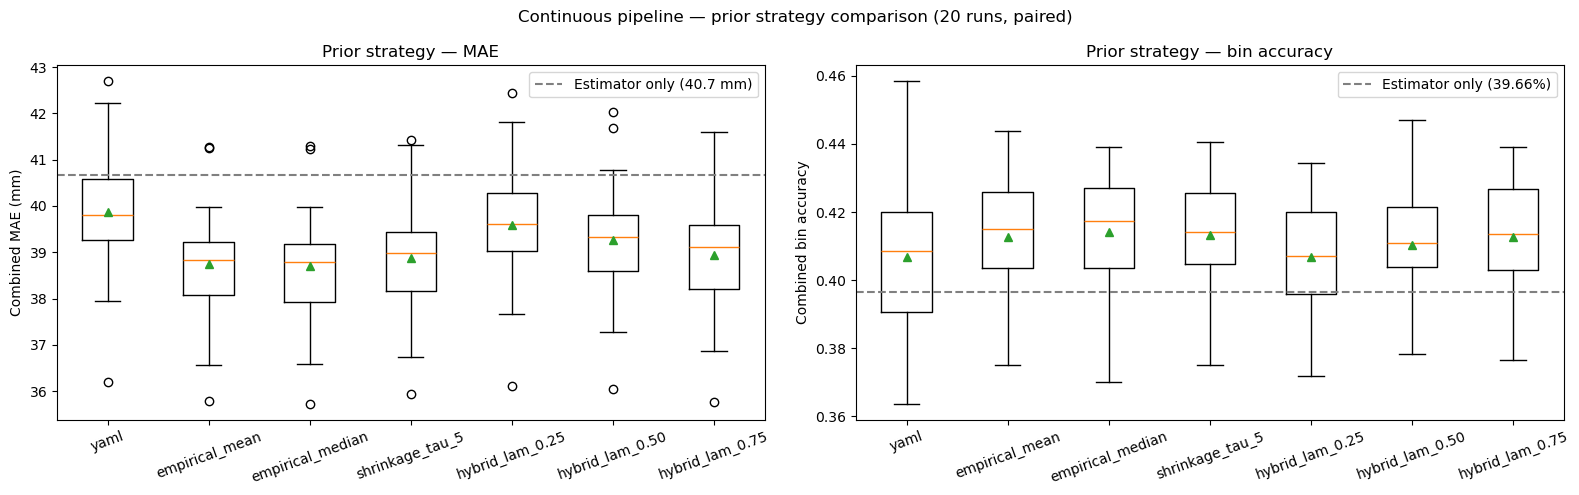

In [40]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"Config":<22} {"MAE (mm)":<18} {"RMSE (mm)":<18} {"Bin acc":<16} {"α":<8}')
print('-' * 82)
for name, _ in PRIOR_CONFIGS:
    df_c = pd.DataFrame(results_by_config[name])
    print(f'{name:<22} '
          f'{df_c["comb_mae_mm"].mean():.1f} ± {df_c["comb_mae_mm"].std():.1f}    '
          f'{df_c["comb_rmse_mm"].mean():.1f} ± {df_c["comb_rmse_mm"].std():.1f}    '
          f'{df_c["comb_bin_acc"].mean():.2%} ± {df_c["comb_bin_acc"].std():.2%}  '
          f'{df_c["best_alpha"].mean():.2f}')

est_mae_mean  = np.mean([r['est_mae_mm']  for r in results_by_config['yaml']])
est_bacc_mean = np.mean([r['est_bin_acc'] for r in results_by_config['yaml']])
print(f'\nEstimator-only baseline: MAE={est_mae_mean:.1f}mm, bin_acc={est_bacc_mean:.2%}')

# ── Paired t-tests vs YAML baseline ───────────────────────────────────────────
# Paired because every config sees the same split + trained estimator each run.
yaml_mae  = np.array([r['comb_mae_mm']  for r in results_by_config['yaml']])
yaml_bacc = np.array([r['comb_bin_acc'] for r in results_by_config['yaml']])

print('\nPaired t-tests vs yaml baseline (per-run differences):')
print(f'  {"Config":<22} {"Δ MAE (mm)":<14} {"p (MAE)":<10}  {"Δ bin_acc":<12} {"p (bacc)":<10}')
for name, _ in PRIOR_CONFIGS:
    if name == 'yaml':
        continue
    other_mae  = np.array([r['comb_mae_mm']  for r in results_by_config[name]])
    other_bacc = np.array([r['comb_bin_acc'] for r in results_by_config[name]])
    # MAE: lower is better, so negative Δ = improvement
    t_mae,  p_mae  = stats.ttest_rel(other_mae,  yaml_mae)
    t_bacc, p_bacc = stats.ttest_rel(other_bacc, yaml_bacc)
    d_mae  = (other_mae  - yaml_mae).mean()
    d_bacc = (other_bacc - yaml_bacc).mean()
    sig_m = '***' if p_mae  < 0.001 else '**' if p_mae  < 0.01 else '*' if p_mae  < 0.05 else ''
    sig_b = '***' if p_bacc < 0.001 else '**' if p_bacc < 0.01 else '*' if p_bacc < 0.05 else ''
    print(f'  {name:<22} {d_mae:+.2f}        {p_mae:.4f} {sig_m:<3} '
          f'{d_bacc:+.2%}      {p_bacc:.4f} {sig_b}')

# ── Box plots: MAE and bin accuracy side by side ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

mae_data  = [[r['comb_mae_mm']  for r in results_by_config[name]] for name, _ in PRIOR_CONFIGS]
bacc_data = [[r['comb_bin_acc'] for r in results_by_config[name]] for name, _ in PRIOR_CONFIGS]
labels    = [name for name, _ in PRIOR_CONFIGS]

ax1.boxplot(mae_data, labels=labels, showmeans=True)
ax1.axhline(est_mae_mean, ls='--', color='gray', label=f'Estimator only ({est_mae_mean:.1f} mm)')
ax1.set_ylabel('Combined MAE (mm)')
ax1.set_title('Prior strategy — MAE')
ax1.legend(); ax1.tick_params(axis='x', rotation=20)

ax2.boxplot(bacc_data, labels=labels, showmeans=True)
ax2.axhline(est_bacc_mean, ls='--', color='gray', label=f'Estimator only ({est_bacc_mean:.2%})')
ax2.set_ylabel('Combined bin accuracy')
ax2.set_title('Prior strategy — bin accuracy')
ax2.legend(); ax2.tick_params(axis='x', rotation=20)

plt.suptitle(f'Continuous pipeline — prior strategy comparison ({NUM_RUNS_EXP} runs, paired)')
plt.tight_layout()
plt.show()